# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayla Poetri Kurnia
- **Email:** cdcc200d6x2356@student.devacademy.id
- **ID Dicoding:** nayla_poetri

## Pertanyaan Bisnis

Analisis ini difokuskan pada periode tahun 2011–2012 sesuai dengan cakupan dataset, dengan tujuan untuk memahami pola dan faktor yang memengaruhi jumlah penyewaan sepeda.

1. Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

2. Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

3. Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

## Import Semua Packages/Library yang Digunakan

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [90]:
# Load dataset
bike_sharing_df = pd.read_csv("data/day.csv")

bike_sharing_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,kategori_sewa,temp_group
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,Low,Medium Temp
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,Low,Medium Temp
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Low,Low Temp
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Low,Low Temp
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Low,Low Temp


**Insight** Dataset berhasil dimuat dan berisi informasi penyewaan sepeda harian, termasuk variabel cuaca, waktu, dan jumlah penyewaan. Struktur data sudah sesuai dan siap untuk proses analisis lebih lanjut.

### Assessing Data

In [91]:
# Menampilkan informasi dataset
bike_sharing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   instant        731 non-null    int64  
 1   dteday         731 non-null    object 
 2   season         731 non-null    object 
 3   yr             731 non-null    int64  
 4   mnth           731 non-null    int64  
 5   holiday        731 non-null    int64  
 6   weekday        731 non-null    int64  
 7   workingday     731 non-null    int64  
 8   weathersit     731 non-null    object 
 9   temp           731 non-null    float64
 10  atemp          731 non-null    float64
 11  hum            731 non-null    float64
 12  windspeed      731 non-null    float64
 13  casual         731 non-null    int64  
 14  registered     731 non-null    int64  
 15  cnt            731 non-null    int64  
 16  kategori_sewa  731 non-null    object 
 17  temp_group     731 non-null    object 
dtypes: float64

In [92]:
# Statistik deskriptif
bike_sharing_df.describe()

,instant,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [93]:
# Mengecek missing values
bike_sharing_df.isnull().sum()  

instant          0
dteday           0
season           0
yr               0
mnth             0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
kategori_sewa    0
temp_group       0
dtype: int64

In [94]:
# Mengecek duplikasi
bike_sharing_df.duplicated().sum()

np.int64(0)

In [95]:
# Mengecek nilai unik pada kolom kategori
bike_sharing_df["season"].value_counts()

season
Fall      188
Summer    184
Spring    181
Winter    178
Name: count, dtype: int64

In [96]:
bike_sharing_df["weathersit"].value_counts()

weathersit
Clear              463
Mist               247
Light Rain/Snow     21
Name: count, dtype: int64

**Insight** Dataset memiliki 731 baris dan 18 kolom dengan tipe data yang sesuai. Tidak ditemukan missing values maupun data duplikat. Variabel kategori seperti season dan weathersit juga memiliki nilai yang konsisten. Secara keseluruhan, kualitas data sudah baik dan siap untuk tahap cleaning dan analisis lebih lanjut.

### Data Cleaning

Pada tahap ini dilakukan transformasi data untuk meningkatkan keterbacaan dan kemudahan analisis.

In [97]:
# Mengubah tipe data kolom tanggal menjadi datetime
bike_sharing_df["dteday"] = pd.to_datetime(bike_sharing_df["dteday"])

bike_sharing_df.dtypes

instant                   int64
dteday           datetime64[ns]
season                   object
yr                        int64
mnth                      int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit               object
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
cnt                       int64
kategori_sewa            object
temp_group               object
dtype: object

In [98]:
# Cek missing value setelah cleaning
bike_sharing_df.isnull().sum()

instant          0
dteday           0
season           0
yr               0
mnth             0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
kategori_sewa    0
temp_group       0
dtype: int64

In [99]:
print("Jumlah duplikasi",  bike_sharing_df.duplicated().sum())

Jumlah duplikasi 0


In [100]:
# Statistik akhir
bike_sharing_df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [101]:
# Menyimpan dataset setelah cleaning
bike_sharing_df.to_csv("dashboard/main_data.csv", index=False)

**Insight** Dataset tidak memiliki missing values maupun duplikasi, dan tipe data sudah sesuai (termasuk konversi `dteday` ke datetime). Data siap digunakan untuk analisis lanjutan.

## Exploratory Data Analysis (EDA)

In [102]:
bike_sharing_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,kategori_sewa,temp_group
669,670,2012-10-31,Winter,1,10,0,3,1,Mist,0.357500,0.361100,0.666667,0.166667,419,5147,5566,Medium,Medium Temp
209,210,2011-07-29,Fall,0,7,0,5,1,Clear,0.838333,0.785967,0.542500,0.174138,670,3176,3846,Medium,High Temp
620,621,2012-09-12,Fall,1,9,0,3,1,Clear,0.599167,0.570075,0.577083,0.131846,1050,6820,7870,High,High Temp
544,545,2012-06-28,Fall,1,6,0,4,1,Clear,0.749167,0.675512,0.422500,0.171650,921,5958,6879,High,High Temp
445,446,2012-03-21,Summer,1,3,0,3,1,Mist,0.531667,0.513258,0.821250,0.089558,1122,5108,6230,High,Medium Temp


In [103]:
bike_sharing_df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### Univariate Analysis

Analisis univariate dilakukan untuk memahami distribusi masing-masing variabel numerik dalam dataset.

Distribusi cnt


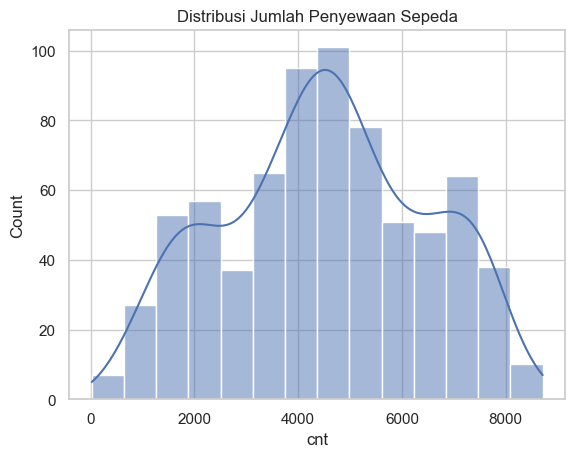

In [104]:
# Menampilkan distribusi jumlah penyewaan sepeda
print("Distribusi cnt")
sns.histplot(bike_sharing_df["cnt"], kde=True)
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.show()

Distribusi `cnt` cenderung mendekati normal dengan sedikit skew ke kanan, menunjukkan mayoritas hari berada pada tingkat penyewaan menengah, dengan beberapa lonjakan tinggi yang dipengaruhi oleh faktor eksternal seperti cuaca dan musim.

Distribusi temp


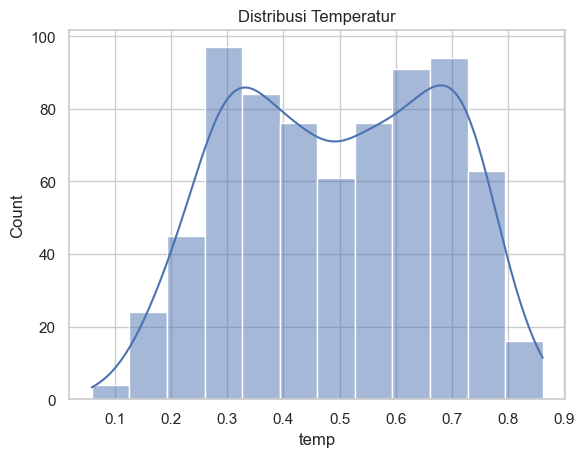

In [105]:
# Menampilkan distribusi temperatur
print("Distribusi temp")
sns.histplot(bike_sharing_df["temp"], kde=True)
plt.title("Distribusi Temperatur")
plt.show()

Distribusi `temp` relatif merata dan mendekati normal, menunjukkan variasi suhu yang cukup luas tanpa dominasi ekstrem. Hal ini mengindikasikan bahwa temperatur berpotensi menjadi faktor penting dalam mempengaruhi jumlah penyewaan sepeda.

Distribusi hum


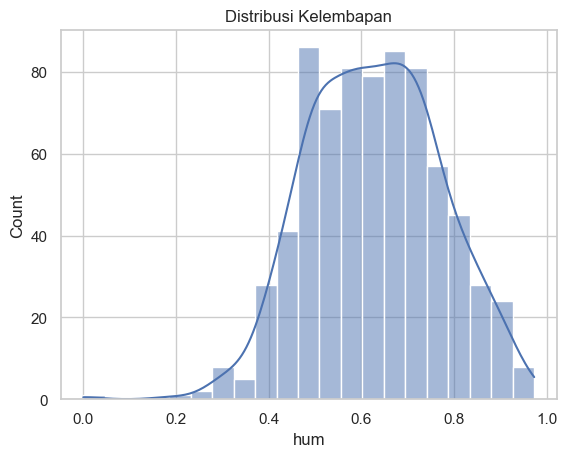

In [106]:
# Menampilkan distribusi kelembapan
print("Distribusi hum")
sns.histplot(bike_sharing_df["hum"], kde=True)
plt.title("Distribusi Kelembapan")
plt.show()

Distribusi `hum` terkonsentrasi pada nilai menengah hingga tinggi dengan sedikit skew ke kanan, menunjukkan dominasi kondisi kelembapan tinggi yang berpotensi mempengaruhi tingkat penyewaan sepeda.

Distribusi windspeed


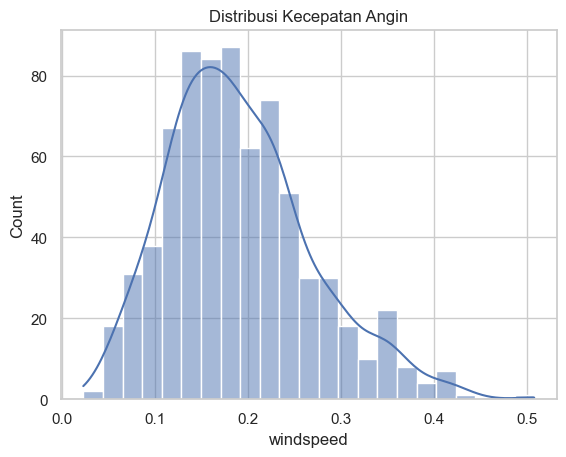

In [107]:
# Menampilkan distribusi kecepatan angin
print("Distribusi windspeed")
sns.histplot(bike_sharing_df["windspeed"], kde=True)
plt.title("Distribusi Kecepatan Angin")
plt.show()

Distribusi `windspeed` cenderung right-skewed, menunjukkan dominasi kecepatan angin rendah hingga sedang, dengan sedikit nilai ekstrem. Kondisi ini berpotensi mempengaruhi tingkat kenyamanan dan jumlah penyewaan sepeda.

Boxplot cnt


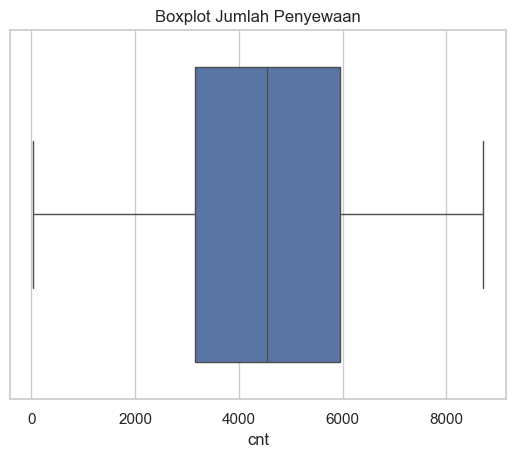

In [108]:
# Boxplot jumlah penyewaan
print("Boxplot cnt")
sns.boxplot(x=bike_sharing_df["cnt"])
plt.title("Boxplot Jumlah Penyewaan")
plt.show()

Distribusi cnt menunjukkan variasi yang cukup besar dengan median di tengah. 
Hal ini menandakan fluktuasi jumlah penyewaan antar hari, tanpa adanya outlier ekstrem yang signifikan.

In [51]:
# Mengecek skewness data
print("Skewness cnt:", bike_sharing_df["cnt"].skew())

Skewness cnt: -0.04735278011900183


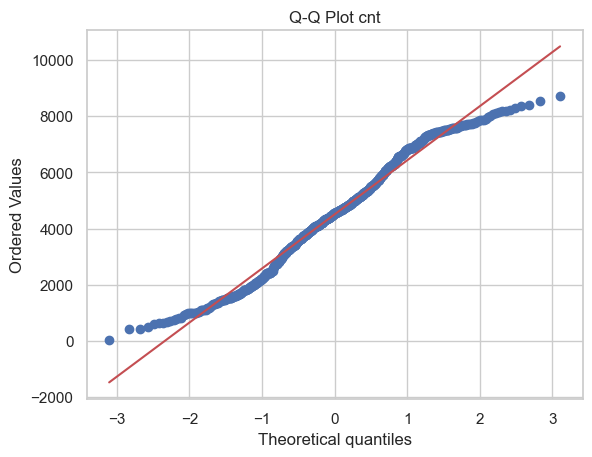

In [53]:
# Q-Q plot untuk melihat distribusi cnt
stats.probplot(bike_sharing_df["cnt"], dist="norm", plot=plt)
plt.title("Q-Q Plot cnt")
plt.show()

Q-Q plot menunjukkan bahwa distribusi `cnt` mendekati normal, meskipun terdapat deviasi pada bagian ekor yang mengindikasikan adanya nilai ekstrem. Hal ini masih wajar dalam data real-world dan tidak memerlukan transformasi signifikan pada tahap eksplorasi.

### Multivariate Analysis

Analisis ini dilakukan untuk memahami hubungan antar variabel numerik dalam dataset.

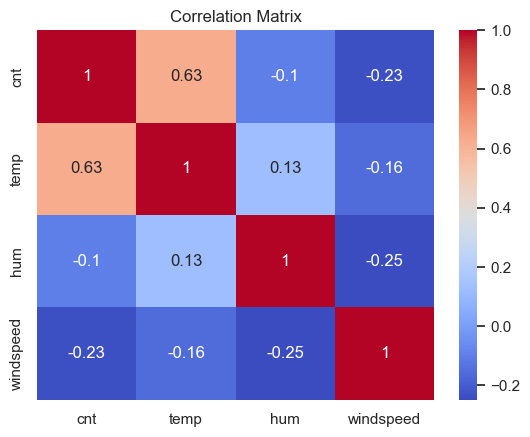

In [88]:
# Korelasi antar variabel utama
cols = ["cnt","temp","hum","windspeed"]

sns.heatmap(bike_sharing_df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Temperatur memiliki korelasi positif terhadap jumlah penyewaan sepeda. 
Sebaliknya, kelembapan dan kecepatan angin memiliki korelasi negatif yang lemah.

Temp vs Cnt


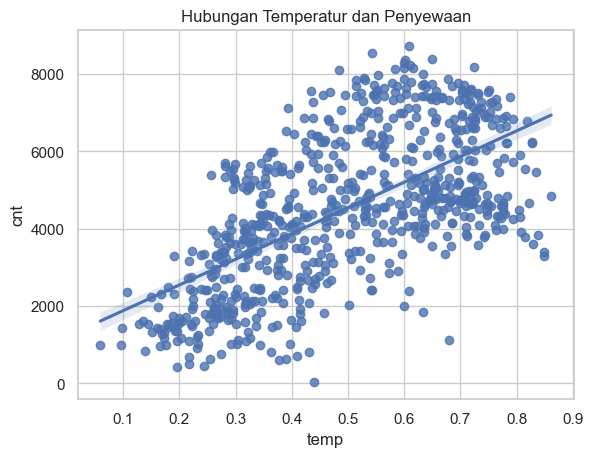

In [55]:
# Hubungan temperatur dengan penyewaan
print("Temp vs Cnt")
sns.regplot(x="temp", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Temperatur dan Penyewaan")
plt.show()

Scatter plot menunjukkan hubungan positif antara `temp` dan `cnt`, di mana peningkatan temperatur cenderung diikuti oleh peningkatan jumlah penyewaan sepeda.

Pola titik yang membentuk tren naik serta garis regresi yang positif memperkuat hasil correlation sebelumnya. Meskipun terdapat variasi data pada setiap tingkat temperatur, tren umum tetap konsisten, yang mengindikasikan bahwa temperatur merupakan salah satu faktor penting dalam memengaruhi permintaan penyewaan sepeda.

Hum vs Cnt


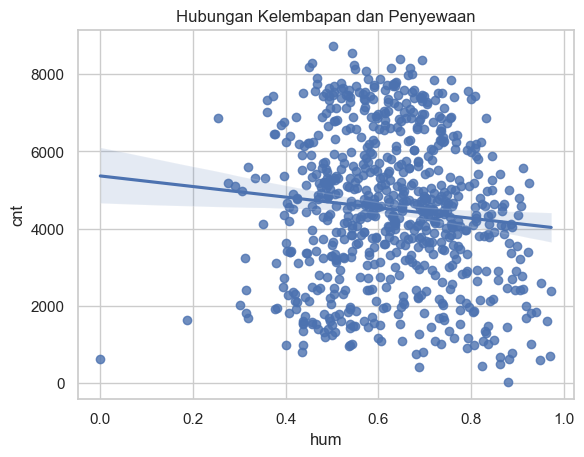

In [56]:
# Hubungan kelembapan dengan penyewaan
print("Hum vs Cnt")
sns.regplot(x="hum", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kelembapan dan Penyewaan")
plt.show()

Scatter plot menunjukkan bahwa `hum` memiliki hubungan negatif yang lemah terhadap `cnt`, di mana peningkatan kelembapan cenderung diikuti oleh sedikit penurunan jumlah penyewaan sepeda.

Namun, penyebaran titik yang cukup luas menunjukkan bahwa hubungan ini tidak terlalu kuat dan dipengaruhi oleh faktor lain. Hal ini mengindikasikan bahwa kelembapan bukan merupakan faktor utama dalam menentukan jumlah penyewaan.

Windspeed vs Cnt


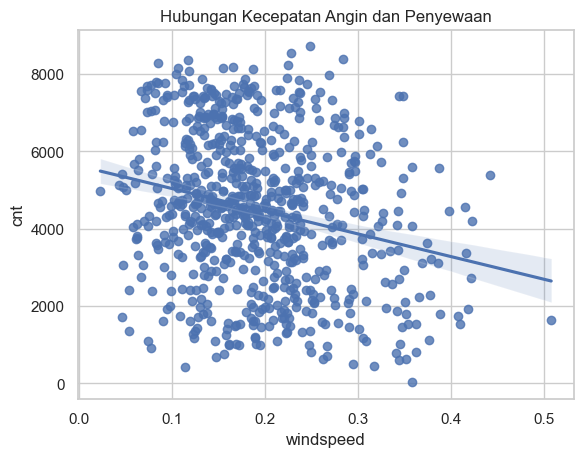

In [57]:
# Hubungan kecepatan angin dengan penyewaan
print("Windspeed vs Cnt")
sns.regplot(x="windspeed", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kecepatan Angin dan Penyewaan")
plt.show()

Scatter plot menunjukkan bahwa `windspeed` memiliki hubungan negatif yang lemah terhadap `cnt`, di mana peningkatan kecepatan angin cenderung diikuti oleh penurunan jumlah penyewaan sepeda.

Namun, penyebaran titik yang cukup luas menunjukkan bahwa hubungan ini tidak kuat, sehingga `windspeed` bukan merupakan faktor utama dalam memengaruhi jumlah penyewaan.

Secara keseluruhan, temperatur merupakan faktor yang paling berpengaruh terhadap jumlah penyewaan sepeda, dengan hubungan positif yang cukup kuat. Sementara itu, kelembapan dan kecepatan angin menunjukkan hubungan negatif yang lemah, sehingga pengaruhnya relatif kecil dibandingkan temperatur.

### Numerical Analysis

Analisis ini dilakukan untuk memahami distribusi statistik data secara lebih mendalam.

In [19]:
# Percentile
df["cnt"].describe(percentiles=[0.05,0.1,0.9,0.95])

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
5%       1331.000000
10%      1746.000000
50%      4548.000000
90%      7290.000000
95%      7576.000000
max      8714.000000
Name: cnt, dtype: float64

Distribusi `cnt` menunjukkan bahwa nilai mean (≈4504) dan median (≈4548) relatif berdekatan, yang mengindikasikan distribusi cukup simetris.

Rentang antara persentil 10% hingga 90% (≈1746–7290) menunjukkan variasi jumlah penyewaan yang cukup besar antar hari. Hal ini diperkuat oleh nilai standar deviasi yang tinggi (~1937), yang menandakan adanya fluktuasi permintaan yang signifikan.

Dengan demikian, meskipun distribusi cenderung stabil secara umum, jumlah penyewaan tetap dipengaruhi oleh faktor eksternal yang menyebabkan variasi harian.

In [86]:
# Standard Deviation
bike_sharing_df.groupby("season")["cnt"].std()

season
Fall      1459.800381
Spring    1399.942119
Summer    1695.977235
Winter    1699.615261
Name: cnt, dtype: float64

In [87]:
bike_sharing_df.groupby("weathersit")["cnt"].std()

weathersit
Clear              1879.483989
Light Rain/Snow    1240.284449
Mist               1809.109918
Name: cnt, dtype: float64

Standar deviasi menunjukkan bahwa variasi jumlah penyewaan paling tinggi terjadi pada kondisi cuaca cerah (~1879) dan berkabut (~1809), sedangkan pada kondisi hujan ringan lebih rendah (~1240).

Hal ini mengindikasikan bahwa pada cuaca baik, permintaan tidak hanya lebih tinggi tetapi juga lebih fluktuatif, kemungkinan dipengaruhi oleh aktivitas pengguna yang lebih dinamis. Sebaliknya, saat hujan ringan, jumlah penyewaan cenderung lebih stabil namun berada pada tingkat yang lebih rendah.

Dengan demikian, kondisi cuaca tidak hanya memengaruhi tingkat penyewaan, tetapi juga tingkat variabilitas permintaan.

### Categorical Analysis

Analisis ini dilakukan untuk melihat perbedaan distribusi jumlah penyewaan berdasarkan kategori.

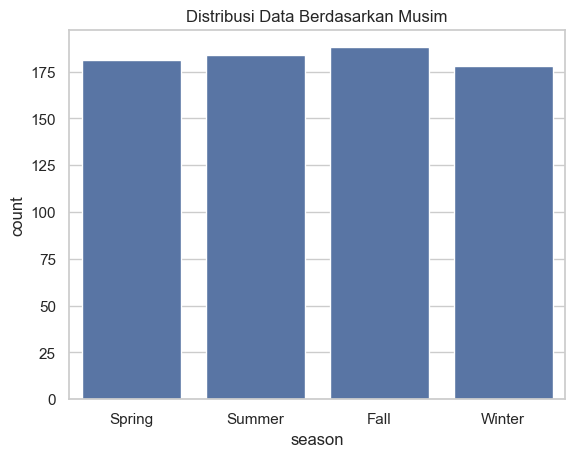

In [21]:
# Countplot Season
sns.countplot(x="season", data=df)
plt.title("Distribusi Data Berdasarkan Musim")
plt.show()

Distribusi data antar musim relatif seimbang, menunjukkan bahwa dataset tidak bias terhadap musim tertentu. Hal ini penting karena analisis selanjutnya dapat dilakukan tanpa khawatir adanya ketidakseimbangan jumlah data pada tiap kategori musim.

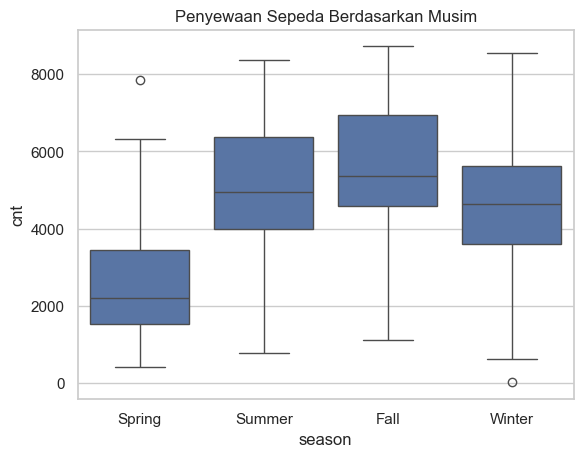

In [22]:
# Boxplot Season vs Cnt
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Penyewaan Sepeda Berdasarkan Musim")
plt.show()

Distribusi jumlah penyewaan menunjukkan bahwa musim Fall dan Summer memiliki median penyewaan yang lebih tinggi dibandingkan musim lainnya, sementara Spring memiliki median terendah.

Selain itu, variasi (IQR) pada Fall dan Summer juga lebih besar, yang mengindikasikan fluktuasi permintaan yang lebih tinggi pada musim tersebut. Hal ini menunjukkan bahwa kondisi cuaca yang lebih hangat cenderung meningkatkan aktivitas penyewaan sepeda.

Sebaliknya, pada musim Spring dan Winter, jumlah penyewaan relatif lebih rendah dan kurang bervariasi.

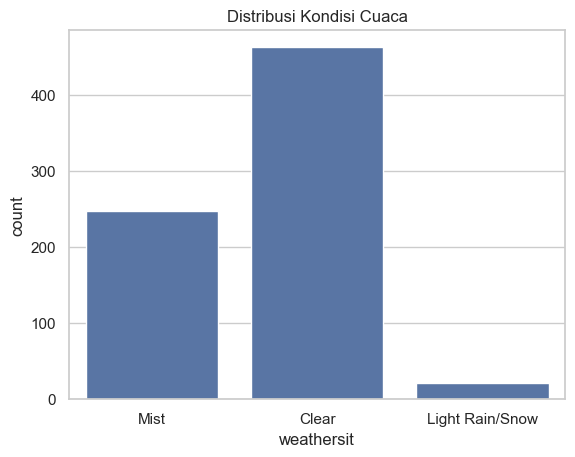

In [23]:
# Countplot Weather
sns.countplot(x="weathersit", data=df)
plt.title("Distribusi Kondisi Cuaca")
plt.show()

Distribusi kondisi cuaca tidak seimbang, dengan mayoritas data berada pada kondisi cerah, diikuti oleh berkabut, dan sangat sedikit pada kondisi hujan ringan/salju.

Ketimpangan ini menunjukkan bahwa analisis lebih banyak merepresentasikan kondisi cuaca normal, sehingga insight yang dihasilkan cenderung bias terhadap kondisi cerah. Sementara itu, pola pada kondisi cuaca ekstrem kurang terwakili dan perlu diinterpretasikan dengan hati-hati.

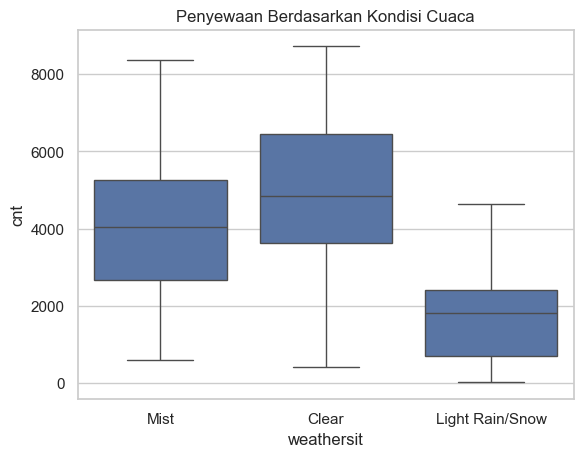

In [24]:
# Boxplot Weather vs Cnt
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Penyewaan Berdasarkan Kondisi Cuaca")
plt.show()

Distribusi jumlah penyewaan menunjukkan bahwa kondisi cuaca cerah memiliki median tertinggi, diikuti oleh berkabut, sementara hujan ringan/salju memiliki median terendah.

Selain itu, variasi penyewaan pada kondisi cerah dan berkabut relatif lebih besar dibandingkan kondisi hujan, yang mengindikasikan bahwa aktivitas penyewaan lebih dinamis saat cuaca baik. Sebaliknya, pada kondisi cuaca buruk, jumlah penyewaan tidak hanya lebih rendah tetapi juga lebih terbatas.

Hal ini menegaskan bahwa kondisi cuaca merupakan faktor penting yang memengaruhi tingkat dan variabilitas permintaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

Temp vs Cnt


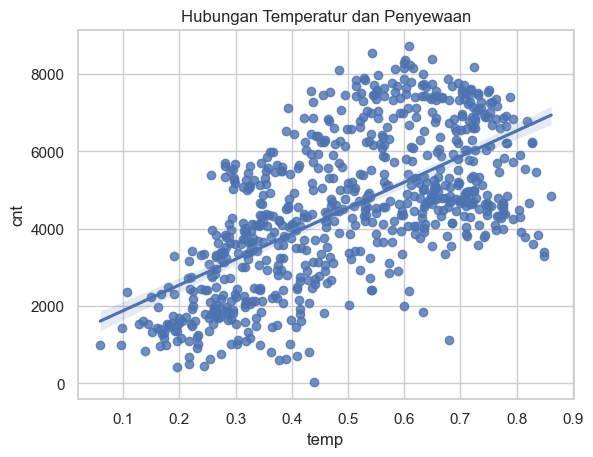

In [58]:
# Hubungan temperatur dengan penyewaan
print("Temp vs Cnt")
sns.regplot(x="temp", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Temperatur dan Penyewaan")
plt.show()

Hum vs Cnt


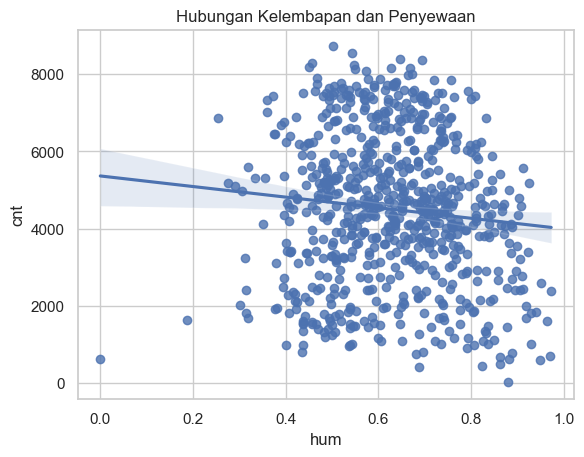

In [60]:
# Hubungan kelembapan dengan penyewaan
print("Hum vs Cnt")
sns.regplot(x="hum", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kelembapan dan Penyewaan")
plt.show()

Windspeed vs Cnt


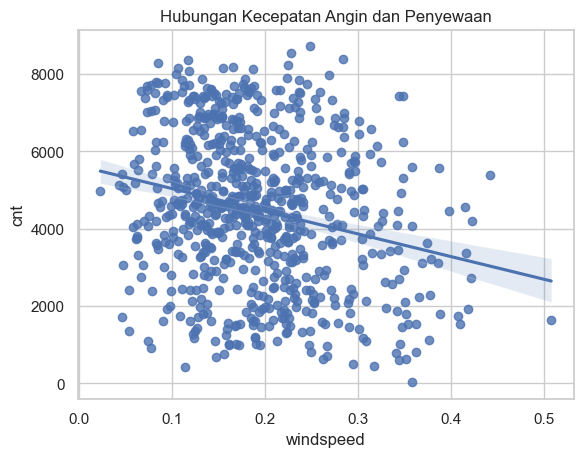

In [59]:
# Hubungan kecepatan angin dengan penyewaan
print("Windspeed vs Cnt")
sns.regplot(x="windspeed", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kecepatan Angin dan Penyewaan")
plt.show()

Berdasarkan visualisasi hubungan antara variabel cuaca dan jumlah penyewaan sepeda pada periode **2011–2012**, terlihat bahwa **temperatur (temp)** memiliki hubungan **positif yang cukup kuat** terhadap jumlah penyewaan sepeda (**cnt**), yang ditunjukkan oleh pola titik yang cenderung meningkat serta garis regresi yang menanjak. Sebaliknya, **kelembapan (hum)** dan **kecepatan angin (windspeed)** menunjukkan hubungan **negatif yang relatif lemah**, terlihat dari garis tren yang menurun dengan sebaran data yang cukup luas dan cenderung acak, sehingga pengaruhnya tidak dominan. Secara keseluruhan, dapat disimpulkan bahwa **temperatur merupakan faktor yang paling berpengaruh** terhadap jumlah penyewaan sepeda, sedangkan **kelembapan dan kecepatan angin hanya memberikan pengaruh tambahan yang relatif kecil**.

### Pertanyaan 2: Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

Season vs Cnt


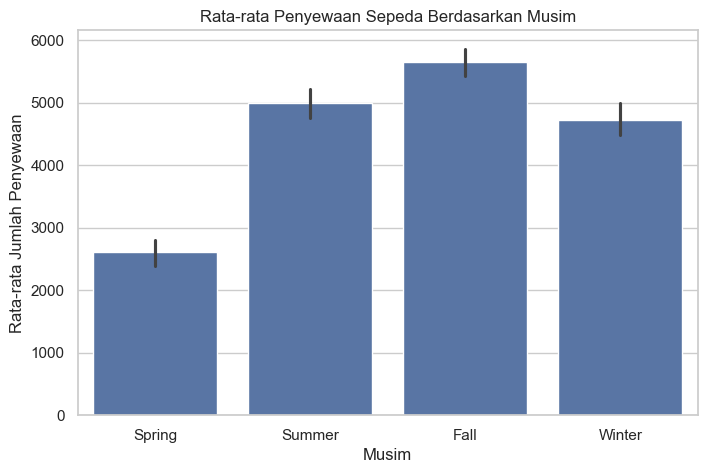

In [61]:
# Rata-rata penyewaan berdasarkan musim
print("Season vs Cnt")

plt.figure(figsize=(8,5))

sns.barplot(
    x="season",
    y="cnt",
    data=df,
    order=["Spring", "Summer", "Fall", "Winter"]
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Jumlah Penyewaan")

plt.show()

Berdasarkan visualisasi rata-rata jumlah penyewaan sepeda berdasarkan musim pada periode **2011–2012**, terlihat bahwa jumlah penyewaan tertinggi terjadi pada **musim gugur (fall)**, diikuti oleh **musim panas (summer)** dan **musim dingin (winter)**, sedangkan **musim semi (spring)** memiliki jumlah penyewaan terendah. Pola ini menunjukkan bahwa kondisi musim memiliki pengaruh terhadap tingkat penyewaan sepeda, di mana cuaca yang lebih nyaman cenderung meningkatkan aktivitas penyewaan. Secara keseluruhan, dapat disimpulkan bahwa **musim merupakan faktor yang memengaruhi variasi jumlah penyewaan sepeda**, dengan puncak aktivitas terjadi pada periode dengan kondisi lingkungan yang lebih mendukung.

### Pertanyaan 3: Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

Trend Bulanan Penyewaan


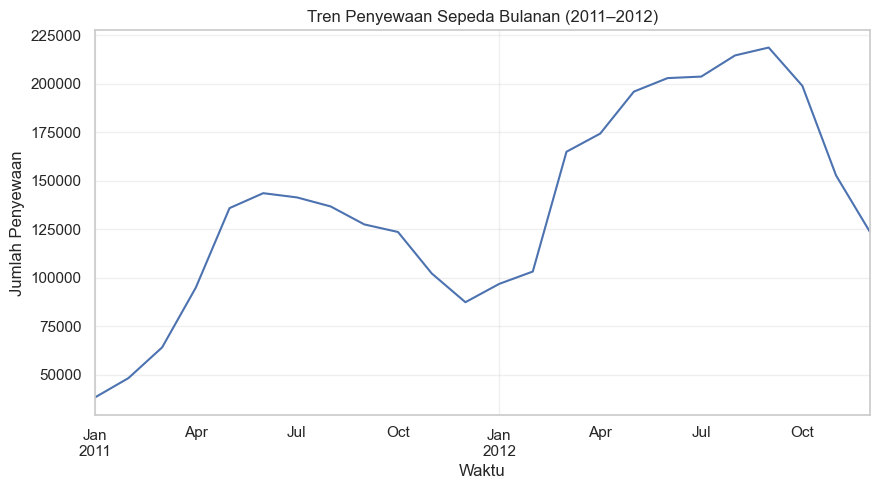

In [63]:
# Tren penyewaan sepeda bulanan
print("Trend Bulanan Penyewaan")

monthly = df.set_index("dteday").resample("ME")["cnt"].sum()

plt.figure(figsize=(10,5))
monthly.plot()

plt.title("Tren Penyewaan Sepeda Bulanan (2011–2012)")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Penyewaan")
plt.grid(alpha=0.3)

plt.show()

Berdasarkan analisis tren bulanan pada periode **Januari 2011 hingga Desember 2012**, terlihat bahwa jumlah penyewaan sepeda menunjukkan pola **fluktuatif dengan kecenderungan meningkat** dari waktu ke waktu. Pada kedua tahun, jumlah penyewaan cenderung meningkat dari awal tahun dan mencapai puncak pada **pertengahan hingga akhir tahun**, kemudian menurun kembali menjelang akhir periode. Selain itu, terlihat bahwa tingkat penyewaan pada **tahun 2012 secara umum lebih tinggi dibandingkan tahun 2011**, yang mengindikasikan adanya peningkatan permintaan secara keseluruhan. Pola ini juga menunjukkan adanya **pengaruh musiman**, di mana periode dengan kondisi cuaca yang lebih mendukung cenderung memiliki jumlah penyewaan yang lebih tinggi.

## Analisis Lanjutan (Opsional)

Pada bagian ini dilakukan analisis tambahan untuk menggali insight lebih dalam terkait faktor-faktor yang memengaruhi jumlah penyewaan sepeda.

### Aggregation Analysis

In [25]:
df.groupby("season")["cnt"].agg(["mean","max","min"])

df.groupby("weathersit")["cnt"].agg(["mean","max","min"])

,mean,max,min
weathersit,,,
Clear,4876.786177,8714,431
Light Rain/Snow,1803.285714,4639,22
Mist,4035.862348,8362,605


Hasil agregasi menunjukkan bahwa kondisi cuaca cerah (Clear) memiliki rata-rata penyewaan tertinggi, diikuti oleh kondisi berkabut (Mist), dan terendah pada kondisi hujan ringan/salju (Light Rain/Snow).

Selain itu, perbedaan nilai maksimum dan minimum menunjukkan bahwa kondisi cuaca tidak hanya memengaruhi rata-rata penyewaan, tetapi juga memengaruhi variasi dan ekstremitas permintaan.

Hal ini menegaskan bahwa faktor cuaca memiliki pengaruh signifikan terhadap pola penyewaan sepeda.

### Binning Analysis (Temperatur)

In [26]:
df["temp_category"] = pd.cut(
    df["temp"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [27]:
temp_summary = df.groupby("temp_category", observed=True)["cnt"].mean()
print(temp_summary)

temp_category
Low       2381.214815
Medium    4488.178363
High      5654.559055
Name: cnt, dtype: float64


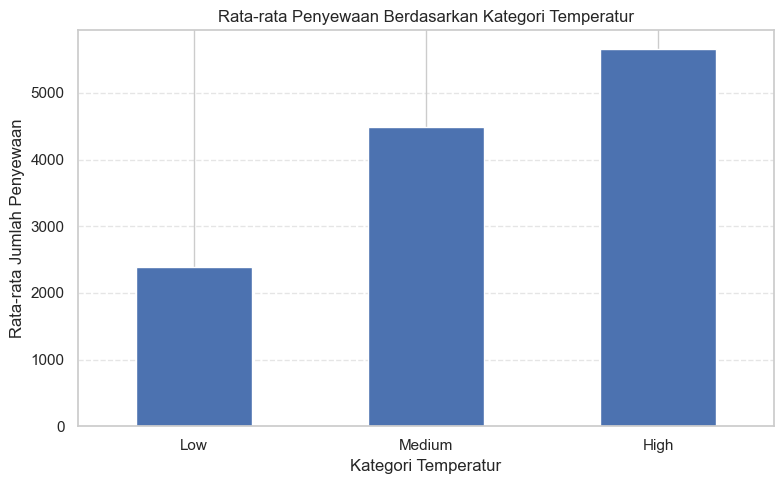

In [38]:
plt.figure(figsize=(8,5))

temp_summary.plot(
    kind="bar",
    color="#4C72B0"
)

plt.title("Rata-rata Penyewaan Berdasarkan Kategori Temperatur")
plt.xlabel("Kategori Temperatur")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Semakin tinggi kategori temperatur, semakin tinggi rata-rata penyewaan sepeda. Hal ini menunjukkan bahwa temperatur memiliki pengaruh positif dan signifikan terhadap permintaan.

### Analisis Kombinasi Musim dan Cuaca

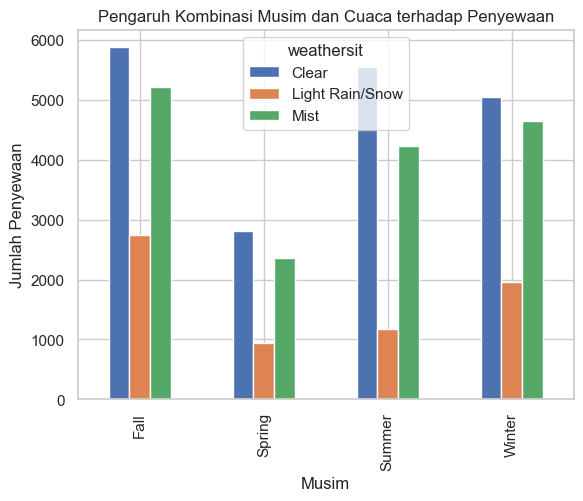

In [26]:
df.groupby(["season","weathersit"])["cnt"].mean().unstack().plot(kind="bar")

plt.title("Pengaruh Kombinasi Musim dan Cuaca terhadap Penyewaan")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

Berdasarkan visualisasi, jumlah penyewaan sepeda dipengaruhi oleh kombinasi antara musim dan kondisi cuaca. Pada kondisi Clear, penyewaan tertinggi terjadi di semua musim, terutama pada Fall dan Summer.

Sebaliknya, pada kondisi Light Rain/Snow, jumlah penyewaan menjadi yang terendah di seluruh musim, menunjukkan bahwa cuaca buruk secara signifikan menurunkan permintaan. Sementara itu, kondisi Mist berada di tingkat menengah.

Hal ini menunjukkan bahwa cuaca merupakan faktor dominan yang dapat memperkuat atau melemahkan pengaruh musim terhadap penyewaan sepeda.

## Conclusion & Recommendation

## Conclusion

- **Conclusion pertanyaan 1:** Temperatur (temp) memiliki hubungan positif yang paling kuat terhadap jumlah penyewaan sepeda (cnt), di mana peningkatan temperatur diikuti oleh peningkatan jumlah penyewaan. Sebaliknya, kelembapan (hum) dan kecepatan angin (windspeed) memiliki hubungan negatif yang relatif lemah, sehingga bukan faktor utama dalam menentukan permintaan.

- **Conclusion pertanyaan 2:** Pola penyewaan sepeda menunjukkan adanya seasonality, di mana jumlah penyewaan tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sedangkan Spring memiliki jumlah penyewaan terendah. Hal ini menunjukkan bahwa kondisi musim berpengaruh terhadap aktivitas penyewaan sepeda.

- **Conclusion pertanyaan 3:** Tren penyewaan sepeda dari Januari 2011 hingga Desember 2012 menunjukkan pola fluktuatif dengan kecenderungan meningkat. Puncak penyewaan terjadi pada pertengahan hingga akhir tahun, dan secara umum tingkat penyewaan pada tahun 2012 lebih tinggi dibandingkan tahun 2011.

## Rekomendasi

- Optimalisasi ketersediaan sepeda pada periode high demand (Summer–Fall) dengan meningkatkan jumlah unit dan kesiapan operasional  
- Menggunakan temperatur sebagai indikator utama dalam memprediksi permintaan penyewaan  
- Menerapkan strategi promosi pada periode permintaan rendah, seperti Spring atau saat kondisi cuaca kurang mendukung  
- Memanfaatkan tren historis untuk perencanaan distribusi sepeda dan pengelolaan kapasitas secara lebih efisien  